# 1. Input

In [23]:
# Nếu môi trường thiếu thư viện, bỏ comment và chạy một lần:
#%pip install numpy pandas matplotlib scikit-learn scipy ucimlrepo torch torchvision opencv-python scikit-image

from pathlib import Path
import torch 
import torchvision
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
RANDOM_STATE = 42


In [24]:
from torchvision.datasets import ImageFolder
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset = ImageFolder(
    root="tom_jerry_dataset/tom_and_jerry/tom_and_jerry",
    transform=transform
)

print(dataset.classes)
print(dataset.class_to_idx)
print(len(dataset))

['jerry', 'tom', 'tom_jerry_0', 'tom_jerry_1']
{'jerry': 0, 'tom': 1, 'tom_jerry_0': 2, 'tom_jerry_1': 3}
5478


In [25]:
dataset[0]

(tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]),
 0)

In [26]:
dataset[0][:1][0].shape

torch.Size([3, 224, 224])

- Có 5478 ảnh, mỗi ảnh 3 kênh màu, 224x224 pixels.

- Có 4 classification labels : 0 - jerry, 1 - tom, 2 - nhân vật khác, 3 - cả tom và jerry.

# 2. Preprocessing (Loại bỏ viền đen)

In [27]:
import cv2
import numpy as np

def remove_black_border(img):
    # img là ảnh RGB (numpy array)

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Tạo mask các pixel không đen
    mask = gray > 10

    coords = np.argwhere(mask)

    if len(coords) == 0:
        return img

    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1

    cropped = img[y0:y1, x0:x1]

    return cropped

In [28]:
image, label = dataset[0]
image_np = (image.permute(1,2,0).numpy() * 255).astype(np.uint8)

In [29]:
cropped = remove_black_border(image_np)


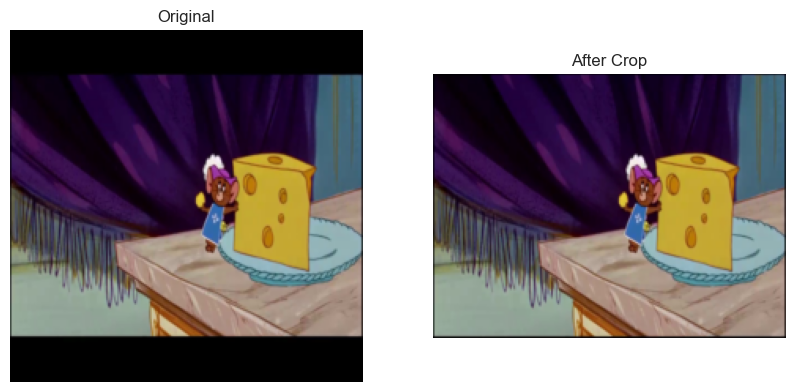

In [30]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_np)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cropped)
plt.title("After Crop")
plt.axis("off")

plt.show()

# 3. HOG + RGB Histogram (Chuẩn hoá và Concat)

In [31]:
import cv2
import numpy as np
from skimage.feature import hog

def extract_feature(img):
    img = remove_black_border(img)
    img = cv2.resize(img, (128, 128))

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )
    gray = clahe.apply(gray)

    hog_feature = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )

    hist = []
    for c in range(3):
        h = cv2.calcHist([img], [c], None, [32], [0, 256])
        h = cv2.normalize(h, h).flatten()
        hist.extend(h)

    hist = np.array(hist)

    feature = np.concatenate([
        hog_feature,
        hist * 5
    ])

    return feature

- Một bức ảnh resize có tổng cộng 128x128 pixels.

- Một cell có kích thước 8x8 pixels

- Có 128 : 8 = 16 ô chiều ngang 

- Có 128 : 8 = 16 ô chiều dọc 

Vậy ảnh có 16x16 = 256 cells 

- Orientation = 9 là có 9 features của 1 cell 

- cell per block 2x2 ghép 4 cell lại 9x4 = 36 features trong 1 block 

- Một ảnh có 16x16 cells, trượt 2x2, có 15x15 blocks

- Vậy tổng có 36x15x15 = 8100 features trong 1 ảnh 




RGB chia 3 kênh màu, mỗi kênh màu 32 bins, vậy mỗi kênh sẽ có 32 features 

Tổng 3 kênh màu sẽ là 32x3 = 96 features

Vậy tổng cộng sẽ có 8100 + 96 = 8196 features trong 1 ảnh, và có 5478 tấm ảnh như vậy 

In [32]:
X = []
y = []

for image, label in dataset:
    # Tensor -> NumPy uint8
    img = (image.permute(1, 2, 0).numpy() * 255).astype(np.uint8)

    # Crop viền đen
    img = remove_black_border(img)

    # Resize về 128x128
    img = cv2.resize(img, (224, 224), interpolation=cv2.INTER_AREA)

    # Trích đặc trưng
    feature = extract_feature(img)

    X.append(feature)
    y.append(label)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5478, 8196)
y shape: (5478,)


# 4. Chia tập train/test

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [35]:
pca = PCA(
    n_components=0.99,
    random_state=42
)

X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)
print(X_train.shape)
print(pca.n_components_)

(4382, 2297)
2297


In [36]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

svm = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    decision_function_shape="ovo",
    random_state=42
)

# 5. Training model

In [37]:
svm.fit(X_train, y_train)

,C,10
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


# 6. Evaluation

In [38]:
y_pred = svm.predict(X_test)

# 7. Report 

In [39]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision :", precision)
print("Recall    :",recall)
print("F1-score  :",f1)
print(classification_report(y_test, y_pred))

Accuracy: 0.8102189781021898
Precision : 0.8164609145260584
Recall    : 0.8102189781021898
F1-score  : 0.8107895180138499
              precision    recall  f1-score   support

           0       0.85      0.74      0.79       248
           1       0.83      0.86      0.84       386
           2       0.72      0.82      0.77       306
           3       0.91      0.78      0.84       156

    accuracy                           0.81      1096
   macro avg       0.83      0.80      0.81      1096
weighted avg       0.82      0.81      0.81      1096



# 8. Confusion matrix visualization

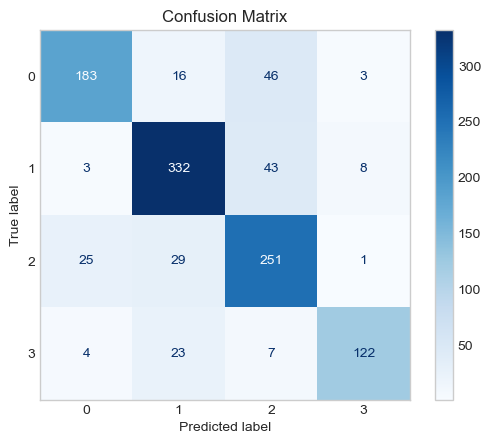

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    svm,
    X_test,
    y_test,
    cmap="Blues",
)
plt.grid(False)
plt.title("Confusion Matrix")
plt.show()